# Example1) PCA 2D to 1D

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Create 2D dataset


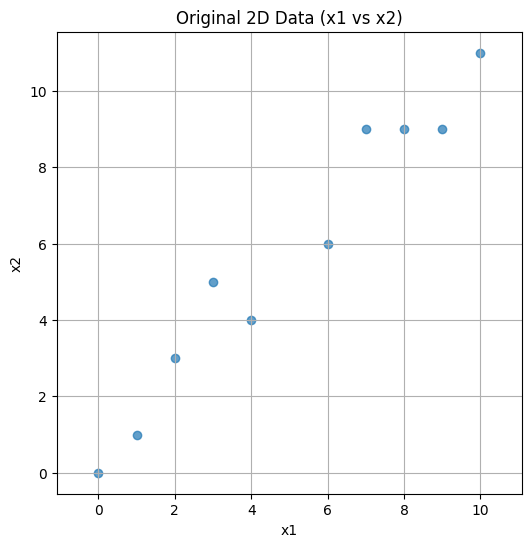

In [2]:
np.random.seed(42)
n_samples = 10

# Create data along x1 ≈ x2 with some noise
x = np.linspace(0, 10, n_samples)
x = np.round(x).astype(int)

y = x + np.random.normal(0, 1, n_samples)
y = np.round(y).astype(int)

X = np.column_stack((x, y))  # shape (100, 2)

# Plot original data
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.title("Original 2D Data (x1 vs x2)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis('equal')
plt.grid(True)
plt.show()


# Step 1: Standardize the data


In [3]:
X_mean = np.mean(X, axis=0)
print("X_mean:\n", X_mean) # (mean_of_col1, mean_of_col2)

X_std = np.std(X, axis=0)
print("\nX_std:\n", X_std) # # (mstd_of_col1, std_of_col2)

X_scaled = (X - X_mean) / X_std

print("\nStandardized Data:\n", X_scaled)

X_mean:
 [5.  5.7]

X_std:
 [3.31662479 3.55105618]

Standardized Data:
 [[-1.50755672 -1.60515624]
 [-1.20604538 -1.32354989]
 [-0.90453403 -0.76033717]
 [-0.60302269 -0.19712445]
 [-0.30151134 -0.47873081]
 [ 0.30151134  0.08448191]
 [ 0.60302269  0.92930098]
 [ 0.90453403  0.92930098]
 [ 1.20604538  0.92930098]
 [ 1.50755672  1.4925137 ]]


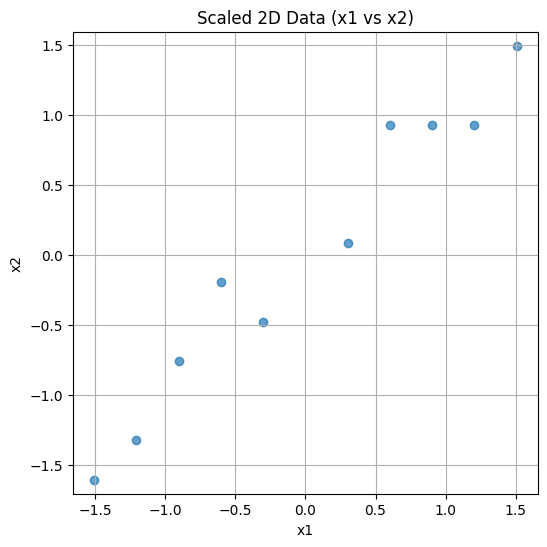

In [14]:
# Plot original data
plt.figure(figsize=(6, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.7)
plt.title("Scaled 2D Data (x1 vs x2)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis('equal')
plt.grid(True)
plt.show()

# Step 2: Compute Covariance Matrix

In [4]:
cov_matrix = np.cov(X_scaled.T)
print("\nCovariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[1.11111111 1.08492932]
 [1.08492932 1.11111111]]


# Step 3: Compute Eigenvalues and Eigenvectors

In [5]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)


Eigenvalues:
 [2.19604043 0.02618179]

Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


# Step 4: Sort Eigenvalues and Select Top k=1

In [6]:

sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("\nSorted Eigenvalues:\n", eigenvalues_sorted)
print("\nSorted Eigenvectors:\n", eigenvectors_sorted)


Sorted Eigenvalues:
 [2.19604043 0.02618179]

Sorted Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


# Step 5: Project Data to 1D

In [7]:

k=1
W = eigenvectors_sorted[:, :k]  # Top-1 component
print(f"\nProjection Matrix W (top {k} eigenvectors):\n", W)
X_pca = X_scaled @ W  # shape (100, 1)


Projection Matrix W (top 1 eigenvectors):
 [[0.70710678]
 [0.70710678]]


In [8]:
print("Original points:\n", X )
print("\nScaled points:\n", X_scaled )
print("\nPoints on PC1:\n", X_pca)

Original points:
 [[ 0  0]
 [ 1  1]
 [ 2  3]
 [ 3  5]
 [ 4  4]
 [ 6  6]
 [ 7  9]
 [ 8  9]
 [ 9  9]
 [10 11]]

Scaled points:
 [[-1.50755672 -1.60515624]
 [-1.20604538 -1.32354989]
 [-0.90453403 -0.76033717]
 [-0.60302269 -0.19712445]
 [-0.30151134 -0.47873081]
 [ 0.30151134  0.08448191]
 [ 0.60302269  0.92930098]
 [ 0.90453403  0.92930098]
 [ 1.20604538  0.92930098]
 [ 1.50755672  1.4925137 ]]

Points on PC1:
 [[-2.20102045]
 [-1.78869396]
 [-1.17724172]
 [-0.56578947]
 [-0.55171452]
 [ 0.27293845]
 [ 1.08351646]
 [ 1.29671718]
 [ 1.50991789]
 [ 2.12137014]]


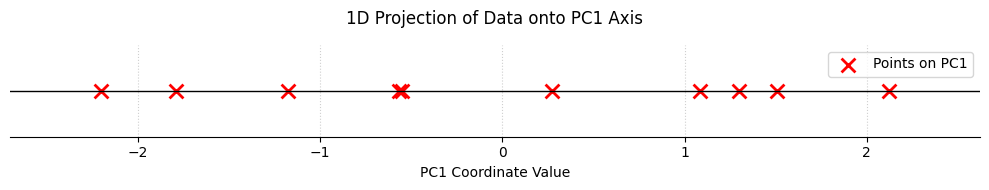

In [15]:
# Lets the points on PC1

# Create an array of zeros for the y-axis
y_zeros = np.zeros_like(X_pca)

# 2. Plotting
plt.figure(figsize=(10, 2))  # Short height to emphasize 1D space

# Plot points on the line
plt.scatter(X_pca, y_zeros, color='red', marker='x', s=100, linewidths=2, label='Points on PC1')

# Draw the single axis line
plt.axhline(0, color='black', linewidth=1)

# Aesthetics
plt.title('1D Projection of Data onto PC1 Axis', fontsize=12, pad=15)
plt.xlabel('PC1 Coordinate Value', fontsize=10)
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Hide the y-axis entirely since it has no meaning here
plt.gca().get_yaxis().set_visible(False)

# Clean up borders
for spine in ['top', 'left', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.xlim(min(X_pca) - 0.5, max(X_pca) + 0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


## Step 6: Reconstruct to Original 2D Space

In [16]:

X_reconstructed = X_pca @ W.T  # shape (100, 2)
X_reconstructed = X_reconstructed * X_std + X_mean  # unscale

top_n=10
print("\nReconstructed Data (Approximate Original):\n", X_reconstructed[:top_n])
print("Actual data:\n",X[:top_n])



Reconstructed Data (Approximate Original):
 [[-0.16185049  0.17329069]
 [ 0.80514082  1.20863255]
 [ 2.23912345  2.74397441]
 [ 3.67310608  4.27931628]
 [ 3.70611476  4.31465814]
 [ 5.64009739  6.38534186]
 [ 7.54107134  8.42068372]
 [ 8.04107134  8.95602559]
 [ 8.54107134  9.49136745]
 [ 9.97505397 11.02670931]]
Actual data:
 [[ 0  0]
 [ 1  1]
 [ 2  3]
 [ 3  5]
 [ 4  4]
 [ 6  6]
 [ 7  9]
 [ 8  9]
 [ 9  9]
 [10 11]]


# Step 7: Plot Reconstructed vs Original


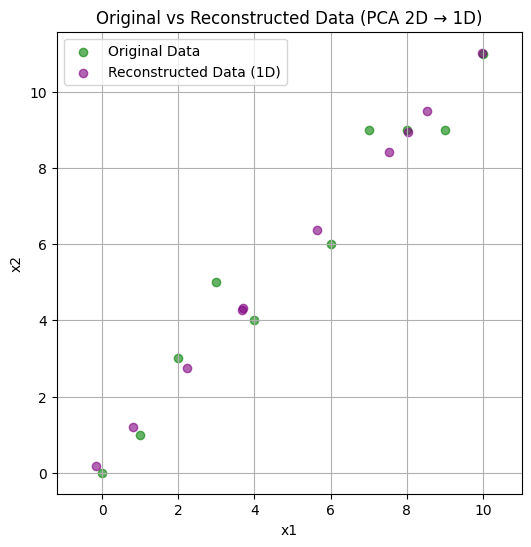


Original Data (first 5 rows):
 [[0 0]
 [1 1]
 [2 3]
 [3 5]
 [4 4]]

Reconstructed Data (first 5 rows):
 [[-0.16185049  0.17329069]
 [ 0.80514082  1.20863255]
 [ 2.23912345  2.74397441]
 [ 3.67310608  4.27931628]
 [ 3.70611476  4.31465814]]


In [17]:

# Assuming X (original data) and X_reconstructed are already defined

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], color='green', alpha=0.6, label='Original Data')
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], color='purple', alpha=0.6, label='Reconstructed Data (1D)')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Original vs Reconstructed Data (PCA 2D → 1D)")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

# Optional: Print a few samples to compare
print("\nOriginal Data (first 5 rows):\n", X[:5])
print("\nReconstructed Data (first 5 rows):\n", X_reconstructed[:5])

# Prettify this

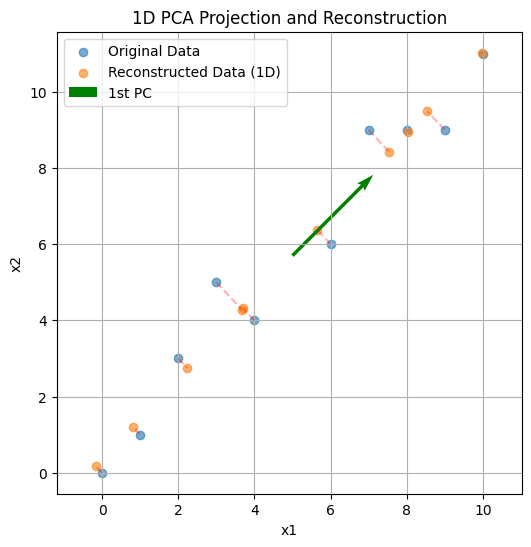

Explained Variance by 1st PC: 98.82%


In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], alpha=0.6, label='Original Data')
ax.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.6, label='Reconstructed Data (1D)')
for i in range(n_samples):
    ax.plot([X[i, 0], X_reconstructed[i, 0]],
            [X[i, 1], X_reconstructed[i, 1]],
            'r--', alpha=0.3)

# Draw first principal component vector
origin = X_mean
pc1_vector = eigenvectors_sorted[:, 0] * 3  # scaled for visualization
ax.quiver(*origin, *pc1_vector, angles='xy', scale_units='xy', scale=1, color='green', label='1st PC')

ax.set_title("1D PCA Projection and Reconstruction")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.axis('equal')
ax.grid(True)
ax.legend()
plt.show()

# --------------------------
# Explained Variance
# --------------------------
explained_variance_ratio = eigenvalues_sorted[0] / np.sum(eigenvalues_sorted)
print(f"Explained Variance by 1st PC: {explained_variance_ratio:.2%}")


# Example 2) PCA: 3D to 2D

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create a sample 3D dataset (10 samples, 3 features)

In [35]:

# Set seed for reproducibility
np.random.seed(42)

# Generate random integers from 0 to 15 inclusive
X = np.random.randint(0, 16, size=(10, 3))

print("Actual data:\n", X)

Actual data:
 [[ 6  3 12]
 [14 10  7]
 [12  4  6]
 [ 9  2  6]
 [10 10  7]
 [ 4  3  7]
 [ 7  2  5]
 [ 4  1  7]
 [11 13  5]
 [ 1 15 11]]


# Step 1: Standardize the data

In [23]:

X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

print("Standardized Data:\n", X_scaled)

Standardized Data:
 [[-0.46229895 -0.67346939  2.09980514]
 [ 1.59236304  0.75510204 -0.13403012]
 [ 1.07869754 -0.46938776 -0.58079717]
 [ 0.3081993  -0.87755102 -0.58079717]
 [ 0.56503205  0.75510204 -0.13403012]
 [-0.97596444 -0.67346939 -0.13403012]
 [-0.2054662  -0.87755102 -1.02756422]
 [-0.97596444 -1.08163265 -0.13403012]
 [ 0.8218648   1.36734694 -1.02756422]
 [-1.74646269  1.7755102   1.65303809]]


In [24]:
# Compare original and scaled

print(X[0], "--->", X_scaled[0])  # 1st point
print(X[1], "--->", X_scaled[1])  # 2nd point


[ 6  3 12] ---> [-0.46229895 -0.67346939  2.09980514]
[14 10  7] ---> [ 1.59236304  0.75510204 -0.13403012]


# Step 2: Compute covariance matrix (features as columns)

In [25]:
cov_matrix = np.cov(X_scaled.T)  # shape: (3, 3)

print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[ 1.11111111  0.11997176 -0.59157118]
 [ 0.11997176  1.11111111  0.20362852]
 [-0.59157118  0.20362852  1.11111111]]


# Step 3: Compute eigenvalues and eigenvectors

In [26]:

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

Eigenvalues:
 [0.4410725  1.70900006 1.18326077]

Eigenvectors:
 [[ 0.65804062 -0.68851856  0.30483558]
 [-0.32434184  0.10617556  0.9399623 ]
 [ 0.67954758  0.71740431  0.15344755]]


In [27]:
# print eigen value and its corresponding eigen vector

print(eigenvalues[0], "-->", eigenvectors[:, 0])
print(eigenvalues[1], "-->", eigenvectors[:, 1])
print(eigenvalues[2], "-->", eigenvectors[:, 2])

0.441072499257265 --> [ 0.65804062 -0.32434184  0.67954758]
1.7090000646535835 --> [-0.68851856  0.10617556  0.71740431]
1.183260769422485 --> [0.30483558 0.9399623  0.15344755]


# Step 4: Sort eigenvalues and eigenvectors in descending order

In [28]:

sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("Sorted Eigenvalues:\n", eigenvalues_sorted)
print("\nSorted Eigenvectors:\n", eigenvectors_sorted)

Sorted Eigenvalues:
 [1.70900006 1.18326077 0.4410725 ]

Sorted Eigenvectors:
 [[-0.68851856  0.30483558  0.65804062]
 [ 0.10617556  0.9399623  -0.32434184]
 [ 0.71740431  0.15344755  0.67954758]]


# Step 5: Select top k eigenvectors (k=2 here)

In [29]:
k = 2
W = eigenvectors_sorted[:, :k]  # projection matrix (3x2)

print(f"Projection Matrix W (top {k} eigenvectors):\n", W)

Projection Matrix W (top 2 eigenvectors):
 [[-0.68851856  0.30483558]
 [ 0.10617556  0.9399623 ]
 [ 0.71740431  0.15344755]]


# Step 6: Transform data to new subspace

In [30]:
X_pca = X_scaled @ W  # shape: (10, 2)

print("\nTransformed Data (Reduced to 2D):\n", X_pca)


Transformed Data (Reduced to 2D):
 [[ 1.75320467 -0.45175104]
 [-1.11235191  1.17460977]
 [-1.20920718 -0.2015033 ]
 [-0.7220418  -0.82003666]
 [-0.40501545  0.86144273]
 [ 0.50430987 -0.95111111]
 [-0.68888617 -1.04517549]
 [ 0.4609729  -1.33476919]
 [-1.15786934  1.37811099]
 [ 2.57688441  1.39018333]]


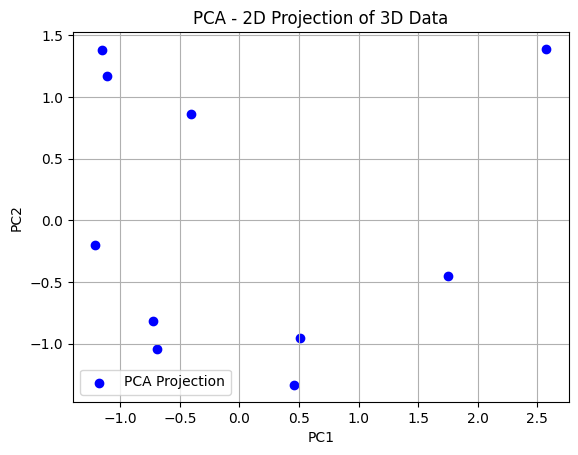

In [31]:
# Optional: Visualize the 2D projection
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='blue', label='PCA Projection')
plt.title("PCA - 2D Projection of 3D Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.legend()
plt.show()


# Step 7 (Optional): Reconstruct original data (approximate)

In [32]:
X_reconstructed = X_pca @ W.T  # shape: (10, 3)
X_reconstructed = (X_reconstructed * X_std) + X_mean  # reverse standardization

print("Actual data:\n",X)
print("\nReconstructed Data (Approximate Original):\n", X_reconstructed)

Actual data:
 [[ 6  3 12]
 [14 10  7]
 [12  4  6]
 [ 9  2  6]
 [10 10  7]
 [ 4  3  7]
 [ 7  2  5]
 [ 4  1  7]
 [11 13  5]
 [ 1 15 11]]

Reconstructed Data (Approximate Original):
 [[ 2.56381513  5.13144082  9.96008088]
 [12.17614672 11.1313231   5.91725465]
 [10.80248398  4.7428106   5.28908487]
 [ 8.76234935  2.14741299  5.85891676]
 [ 9.90821655 10.05693262  6.94551201]
 [ 5.31916679  2.1817303   7.78313411]
 [ 8.40624762  1.12771469  5.83483035]
 [ 4.97997979  0.39212557  7.58177298]
 [12.53970629 12.04493123  5.91405918]
 [ 2.54188778 14.04357807 11.91535423]]


In [28]:
# Analysis
explained_ratio = np.sum(eigenvalues_sorted[:k]) / np.sum(eigenvalues_sorted)
print(f"Explained Variance Ratio: {explained_ratio:.4f}")

Explained Variance Ratio: 0.8391
